# 04 - PCA sobre datos hasta 2025

Este notebook recibe la salida del preprocessing temporalmente filtrado y reduce sus 12 variables a componentes principales.

## Resumen ejecutivo

- **Entrada**: 675 exoplanetas descubiertos hasta 2025.
- **Contrato**: preprocessing ya transformado, escalado e imputado.
- **Objetivo**: conservar al menos el 85 % de la varianza.
- **Entrega**: scores, varianza, loadings, modelo PCA y metadata trazable.

Este notebook no realiza K-Means.

## Bloque 1. Configuración y contrato con preprocessing

Además de las 12 variables, el notebook valida `preprocessing_metadata.json`: debe declarar `max_discovery_year = 2025` y 675 filas retenidas. De este modo PCA no puede ejecutarse accidentalmente sobre la salida antigua con 2026.

In [1]:
# BLOQUE 1 — Importaciones, rutas, variables y parámetros PCA

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
VARIANCE_THRESHOLD = 0.85
EXPECTED_MAX_DISCOVERY_YEAR = 2025
EXPECTED_ROWS = 675

USE_DEMO_DATA = False
PROCESSED_DATA_PATH = Path("data/processed/exoplanets_preprocessed.csv")
PREPROCESSING_METADATA_PATH = Path("data/processed/preprocessing_metadata.json")
RAW_DATA_PATH = Path("data/raw/exoplanets.csv")

FEATURE_COLUMNS = [
    "pl_orbper",
    "pl_orbsmax",
    "pl_rade",
    "pl_bmasse",
    "pl_orbeccen",
    "pl_insol",
    "pl_eqt",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "st_logg",
]

ID_COLUMN = "pl_name"
DATA_ALREADY_SCALED = True
CLUSTER_LABELS_PATH = Path("data/processed/cluster_labels.csv")
CLUSTER_COLUMN = "cluster"
EXPORT_ARTIFACTS = not USE_DEMO_DATA
OUTPUT_DIR = Path("data/processed/pca")

### Conclusión del bloque 1

PCA recibe 12 variables y exige una salida del notebook 03 con 675 planetas y corte máximo en 2025. `pl_name` solo mantiene la trazabilidad.

## Bloque 2. Carga y verificación temporal

Se carga `exoplanets_preprocessed.csv`, se contrasta su metadata y se comprueban los años reales mediante `pl_name`. Cualquier registro de 2026 detiene la ejecución.

In [2]:
# BLOQUE 2A — Localizar las rutas del proyecto

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "README.md").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró la raíz del repositorio. Ejecuta el notebook dentro de exoplanet-profiler."
    )

PROJECT_ROOT = find_project_root()
processed_path = PROJECT_ROOT / PROCESSED_DATA_PATH
preprocessing_metadata_path = PROJECT_ROOT / PREPROCESSING_METADATA_PATH
raw_data_path = PROJECT_ROOT / RAW_DATA_PATH
cluster_labels_path = PROJECT_ROOT / CLUSTER_LABELS_PATH
output_dir = PROJECT_ROOT / OUTPUT_DIR

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Archivo procesado: {processed_path}")
print(f"Metadata preprocessing: {preprocessing_metadata_path}")

Raíz del proyecto: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler
Archivo procesado: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\exoplanets_preprocessed.csv
Metadata preprocessing: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\preprocessing_metadata.json


In [3]:
# BLOQUE 2B — Cargar y validar la salida temporal del notebook 03

def make_demo_dataset(n_rows: int = 240, random_state: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    orbital = rng.normal(size=n_rows)
    planet = rng.normal(size=n_rows)
    stellar = rng.normal(size=n_rows)
    noise = lambda scale=0.25: rng.normal(scale=scale, size=n_rows)
    return pd.DataFrame(
        {
            ID_COLUMN: [f"DEMO-{index:03d}" for index in range(1, n_rows + 1)],
            "pl_orbper": 1.10 * orbital + noise(),
            "pl_orbsmax": 0.95 * orbital + noise(),
            "pl_rade": 0.90 * planet + noise(),
            "pl_bmasse": 1.05 * planet + noise(0.35),
            "pl_orbeccen": 0.25 * orbital + noise(0.75),
            "pl_insol": -0.75 * orbital + 0.45 * stellar + noise(),
            "pl_eqt": -0.65 * orbital + 0.55 * stellar + noise(),
            "st_teff": 1.05 * stellar + noise(),
            "st_rad": 0.85 * stellar + noise(),
            "st_mass": 0.90 * stellar + noise(),
            "st_met": 0.30 * stellar + noise(0.60),
            "st_logg": -0.55 * stellar + noise(0.45),
        }
    )

if USE_DEMO_DATA:
    df = make_demo_dataset(random_state=RANDOM_STATE)
    preprocessing_metadata = {}
    source_mode = "DEMO SINTÉTICA"
else:
    for required_path in [
        processed_path,
        preprocessing_metadata_path,
        raw_data_path,
    ]:
        if not required_path.exists():
            raise FileNotFoundError(f"No existe {required_path}.")

    df = pd.read_csv(processed_path)
    preprocessing_metadata = json.loads(
        preprocessing_metadata_path.read_text(encoding="utf-8")
    )

    assert preprocessing_metadata["max_discovery_year"] == EXPECTED_MAX_DISCOVERY_YEAR
    assert preprocessing_metadata["rows_retained"] == EXPECTED_ROWS
    assert len(df) == EXPECTED_ROWS

    raw_years = pd.read_csv(
        raw_data_path,
        usecols=[ID_COLUMN, "disc_year"],
    ).drop_duplicates(ID_COLUMN)
    year_check = df[[ID_COLUMN]].merge(
        raw_years,
        on=ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
    assert year_check["disc_year"].notna().all()
    assert year_check["disc_year"].max() <= EXPECTED_MAX_DISCOVERY_YEAR
    assert not year_check["disc_year"].eq(2026).any()

    source_mode = "DATOS REALES PREPROCESADOS HASTA 2025"

print(f"Modo de ejecución: {source_mode}")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())

Modo de ejecución: DATOS REALES PREPROCESADOS HASTA 2025
Dimensiones: 675 filas x 13 columnas


,pl_name,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_met,st_logg
0,pi Men c,0.105507,0.048817,-0.286805,-0.329672,-0.307143,0.272774,0.331539,0.357736,0.436978,0.352584,0.074074,-0.147139
1,LHS 3844 b,-1.264902,-0.796278,-0.494602,-0.643283,-0.307143,-0.018919,-0.085635,-1.181902,-1.349148,-1.509625,0.555556,1.596730
2,HD 202772 A b,-0.341416,-0.086401,1.097028,0.694155,-0.092857,1.089863,1.799724,0.592006,1.901668,1.671733,0.600000,-1.509537
3,GJ 143 b,1.487810,1.896600,-0.153188,-0.072130,1.035714,-0.510682,-0.629834,-0.358792,-0.296469,-0.336373,-0.248148,0.351499
4,HD 23472 b,0.911929,0.856322,-0.291497,-0.345417,0.207143,-0.437287,-0.462707,-0.335576,-0.270311,-0.457953,-1.000000,0.125341


### Conclusión del bloque 2

La entrada tiene **675 filas y 13 columnas**. La metadata y el catálogo confirman que ningún descubrimiento de 2026 entra en PCA.

## Bloque 3. Validación del contrato de entrada


PCA no admite valores ausentes y sería incoherente con columnas no numéricas, infinitos o identificadores repetidos. La función de validación comprueba esos requisitos y devuelve únicamente la matriz de características. Después se confirma si hace falta escalar.

In [4]:
# BLOQUE 3A — Validar identificador, columnas, tipos y valores


def validate_pca_input(
    data: pd.DataFrame,
    feature_columns: list[str],
    id_column: str,
) -> pd.DataFrame:
    # Valida que el dataset pueda utilizarse en PCA y devuelve la matriz numérica.
    required_columns = [id_column, *feature_columns]
    missing_columns = [column for column in required_columns if column not in data.columns]
    if missing_columns:
        raise ValueError(f"Faltan columnas requeridas: {missing_columns}")

    if data.empty:
        raise ValueError("El dataset está vacío.")
    if len(feature_columns) < 2:
        raise ValueError("PCA necesita al menos dos variables.")
    if data[id_column].isna().any():
        raise ValueError(f"{id_column} contiene valores nulos.")
    if data[id_column].duplicated().any():
        duplicated = data.loc[data[id_column].duplicated(), id_column].head().tolist()
        raise ValueError(f"{id_column} contiene duplicados, por ejemplo: {duplicated}")

    feature_frame = data.loc[:, feature_columns].copy()
    non_numeric = feature_frame.select_dtypes(exclude=np.number).columns.tolist()
    if non_numeric:
        raise TypeError(f"Las siguientes columnas no son numéricas: {non_numeric}")
    if feature_frame.isna().any().any():
        null_counts = feature_frame.isna().sum()
        raise ValueError(
            "PCA no admite nulos. Columnas afectadas: "
            + str(null_counts[null_counts > 0].to_dict())
        )
    if not np.isfinite(feature_frame.to_numpy()).all():
        raise ValueError("La matriz contiene valores infinitos o no finitos.")
    if len(feature_frame) < len(feature_columns):
        warnings.warn(
            "Hay menos observaciones que variables; revisa si la muestra es suficiente.",
            stacklevel=2,
        )

    return feature_frame


X_input = validate_pca_input(df, FEATURE_COLUMNS, ID_COLUMN)

input_diagnostics = pd.DataFrame(
    {
        "dtype": X_input.dtypes.astype(str),
        "nulos": X_input.isna().sum(),
        "media": X_input.mean(),
        "desviacion_estandar": X_input.std(ddof=0),
        "minimo": X_input.min(),
        "maximo": X_input.max(),
    }
)

display(input_diagnostics.round(4))

,dtype,nulos,media,desviacion_estandar,minimo,maximo
pl_orbper,float64,0,0.1824,0.8599,-1.4075,5.2228
pl_orbsmax,float64,0,0.4523,1.6365,-0.7963,25.8884
pl_rade,float64,0,0.1957,0.5380,-0.7773,1.3221
pl_bmasse,float64,0,0.0558,0.5773,-0.8882,1.5945
pl_orbeccen,float64,0,0.3726,0.9773,-0.3071,6.4157
pl_insol,float64,0,0.0639,0.5228,-1.1912,1.1861
pl_eqt,float64,0,0.1392,0.6615,-0.9876,3.8232
st_teff,float64,0,-0.1460,0.5597,-1.3033,1.6779
st_rad,float64,0,0.0637,0.7514,-1.8245,2.9739
st_mass,float64,0,-0.0514,0.6971,-1.5765,2.0344


In [5]:
# BLOQUE 3B — Confirmar la escala de entrada


if DATA_ALREADY_SCALED:
    X_scaled = X_input.copy()
    scaler_used_here = None
else:
    scaler_used_here = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler_used_here.fit_transform(X_input),
        columns=FEATURE_COLUMNS,
        index=X_input.index,
    )
    warnings.warn(
        "El escalado se ha realizado en este notebook. Documenta esta decisión con el miembro 2.",
        stacklevel=2,
    )

scale_check = pd.DataFrame(
    {
        "media": X_scaled.mean(),
        "desviacion_estandar": X_scaled.std(ddof=0),
    }
)
display(scale_check.round(4))

if DATA_ALREADY_SCALED and (X_scaled.std(ddof=0) == 0).any():
    constant_columns = X_scaled.columns[X_scaled.std(ddof=0) == 0].tolist()
    raise ValueError(f"Hay variables constantes que deben retirarse: {constant_columns}")

,media,desviacion_estandar
pl_orbper,0.1824,0.8599
pl_orbsmax,0.4523,1.6365
pl_rade,0.1957,0.5380
pl_bmasse,0.0558,0.5773
pl_orbeccen,0.3726,0.9773
pl_insol,0.0639,0.5228
pl_eqt,0.1392,0.6615
st_teff,-0.1460,0.5597
st_rad,0.0637,0.7514
st_mass,-0.0514,0.6971


### Conclusión del bloque 3

Las 12 variables son numéricas, no contienen nulos ni infinitos y ninguna es constante. No se vuelve a escalar: se utiliza directamente la salida robusta del preprocessing.

## Bloque 4. Ajuste de PCA y selección de componentes


Primero se ajusta un PCA completo para conocer la varianza de todas las componentes. `np.searchsorted` localiza el primer punto donde la varianza acumulada alcanza el 85 %. Después se reajusta PCA conservando solo ese número de componentes y se calculan los scores de cada planeta.

In [7]:
# BLOQUE 4 — Ajustar PCA y calcular los scores


full_pca = PCA(svd_solver="full")
full_pca.fit(X_scaled)

explained_variance = pd.DataFrame(
    {
        "componente": np.arange(1, full_pca.n_components_ + 1),
        "varianza_explicada": full_pca.explained_variance_ratio_,
        "varianza_acumulada": np.cumsum(full_pca.explained_variance_ratio_),
    }
)

n_components = int(
    np.searchsorted(
        explained_variance["varianza_acumulada"].to_numpy(),
        VARIANCE_THRESHOLD,
    )
    + 1
)

pca_model = PCA(n_components=n_components, svd_solver="full")
scores_array = pca_model.fit_transform(X_scaled)
component_names = [f"PC{index}" for index in range(1, n_components + 1)]

scores_df = pd.DataFrame(scores_array, columns=component_names, index=df.index)
scores_df.insert(0, ID_COLUMN, df[ID_COLUMN].values)

retained_variance = float(pca_model.explained_variance_ratio_.sum())

print(f"Umbral configurado: {VARIANCE_THRESHOLD:.0%}")
print(f"Componentes retenidos: {n_components}")
print(f"Varianza explicada retenida: {retained_variance:.2%}")
display(explained_variance.round(4))

Umbral configurado: 85%
Componentes retenidos: 4
Varianza explicada retenida: 90.20%


,componente,varianza_explicada,varianza_acumulada
0,1,0.4402,0.4402
1,2,0.3020,0.7422
2,3,0.0960,0.8381
3,4,0.0639,0.9020
4,5,0.0365,0.9385
5,6,0.0304,0.9689
6,7,0.0182,0.9871
7,8,0.0040,0.9911
8,9,0.0033,0.9944
9,10,0.0032,0.9976


### Conclusión del bloque 4

Tres componentes explican el **83,81 %**, por debajo del umbral del 85 %. Con **4 componentes se alcanza el 90,20 %**, por lo que PC1–PC4 forman la representación entregada al clustering.

## Bloque 5. Visualización de la varianza explicada


El gráfico de barras muestra la aportación individual de cada componente y la curva muestra la acumulada. Las líneas de referencia permiten ver el umbral y el punto de corte elegido por el código.

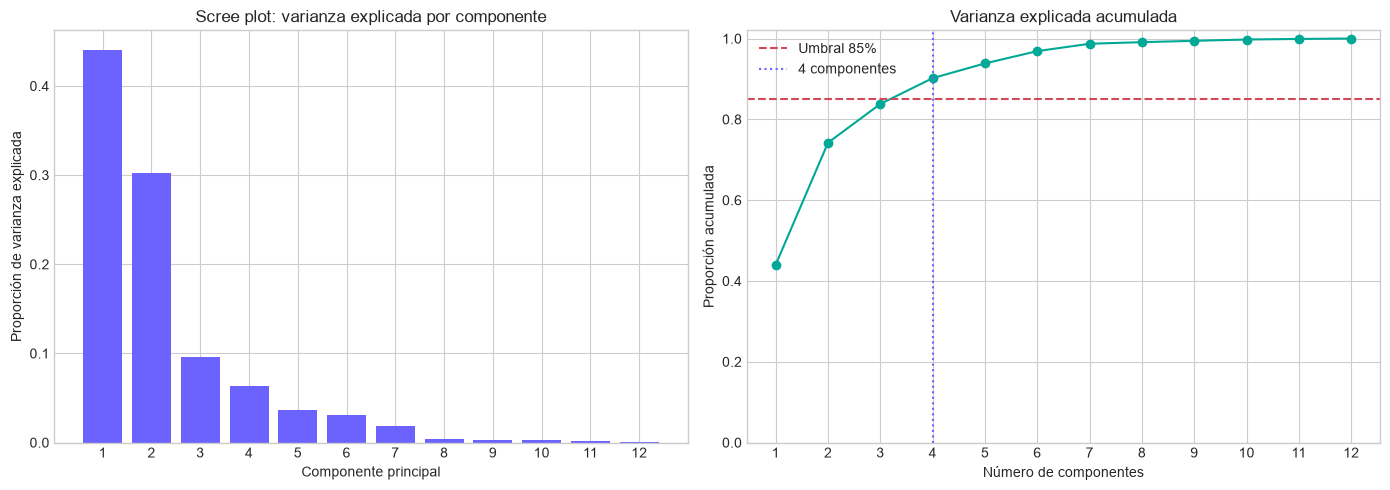

In [8]:
# BLOQUE 5 — Dibujar la varianza individual y acumulada


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    explained_variance["componente"],
    explained_variance["varianza_explicada"],
    color="#6C63FF",
)
axes[0].set(
    title="Scree plot: varianza explicada por componente",
    xlabel="Componente principal",
    ylabel="Proporción de varianza explicada",
)
axes[0].set_xticks(explained_variance["componente"])

axes[1].plot(
    explained_variance["componente"],
    explained_variance["varianza_acumulada"],
    marker="o",
    color="#00A896",
)
axes[1].axhline(
    VARIANCE_THRESHOLD,
    color="#D1495B",
    linestyle="--",
    label=f"Umbral {VARIANCE_THRESHOLD:.0%}",
)
axes[1].axvline(n_components, color="#6C63FF", linestyle=":", label=f"{n_components} componentes")
axes[1].set(
    title="Varianza explicada acumulada",
    xlabel="Número de componentes",
    ylabel="Proporción acumulada",
    ylim=(0, 1.02),
)
axes[1].set_xticks(explained_variance["componente"])
axes[1].legend()

plt.tight_layout()
plt.show()

### Conclusión del bloque 5

PC1 explica **44,02 %**, PC2 **30,20 %**, PC3 **9,60 %** y PC4 **6,39 %**. Las cuatro acumulan **90,20 %** de la varianza.

## Bloque 6. Loadings e interpretación física


Los *loadings* son los pesos de las variables originales dentro de cada componente. El mapa de calor permite comparar signo y magnitud; la tabla adicional selecciona las tres contribuciones absolutas más fuertes de cada componente. El signo global puede invertirse sin alterar la solución.

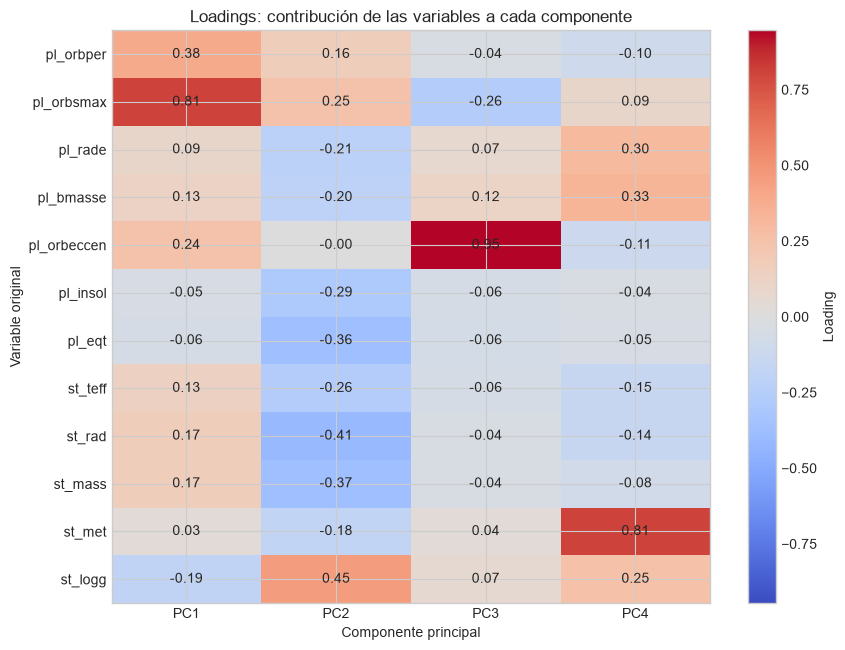

,PC1,PC2,PC3,PC4
pl_orbper,0.385,0.165,-0.044,-0.103
pl_orbsmax,0.808,0.249,-0.259,0.089
pl_rade,0.094,-0.215,0.067,0.296
pl_bmasse,0.125,-0.202,0.116,0.326
pl_orbeccen,0.245,-0.001,0.945,-0.115
pl_insol,-0.049,-0.293,-0.056,-0.044
pl_eqt,-0.058,-0.364,-0.063,-0.050
st_teff,0.132,-0.264,-0.057,-0.147
st_rad,0.166,-0.407,-0.044,-0.144
st_mass,0.166,-0.365,-0.041,-0.084


In [9]:
# BLOQUE 6A — Calcular y visualizar los loadings


loadings_df = pd.DataFrame(
    pca_model.components_.T,
    index=FEATURE_COLUMNS,
    columns=component_names,
)

fig_width = max(8, 1.2 * n_components + 4)
fig, ax = plt.subplots(figsize=(fig_width, max(5, 0.55 * len(FEATURE_COLUMNS))))
max_abs_loading = max(0.01, float(np.abs(loadings_df.to_numpy()).max()))
image = ax.imshow(
    loadings_df.to_numpy(),
    cmap="coolwarm",
    vmin=-max_abs_loading,
    vmax=max_abs_loading,
    aspect="auto",
)
ax.set_xticks(np.arange(len(loadings_df.columns)), labels=loadings_df.columns)
ax.set_yticks(np.arange(len(loadings_df.index)), labels=loadings_df.index)
for row in range(loadings_df.shape[0]):
    for column in range(loadings_df.shape[1]):
        ax.text(column, row, f"{loadings_df.iloc[row, column]:.2f}", ha="center", va="center")
ax.set_title("Loadings: contribución de las variables a cada componente")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Variable original")
fig.colorbar(image, ax=ax, label="Loading")
fig.tight_layout()
plt.show()

display(loadings_df.round(3))

In [11]:
# BLOQUE 6B — Extraer las variables dominantes


def strongest_loadings(loadings: pd.DataFrame, top_n: int = 3) -> pd.DataFrame:
    # Devuelve las variables con mayor loading absoluto para cada componente.
    records = []
    for component in loadings.columns:
        ranked = loadings[component].abs().nlargest(min(top_n, len(loadings)))
        for rank, feature in enumerate(ranked.index, start=1):
            records.append(
                {
                    "componente": component,
                    "posicion": rank,
                    "variable": feature,
                    "loading": loadings.loc[feature, component],
                    "loading_absoluto": abs(loadings.loc[feature, component]),
                }
            )
    return pd.DataFrame(records)


top_loadings_df = strongest_loadings(loadings_df, top_n=3)
display(top_loadings_df.round(3))

,componente,posicion,variable,loading,loading_absoluto
0,PC1,1,pl_orbsmax,0.808,0.808
1,PC1,2,pl_orbper,0.385,0.385
2,PC1,3,pl_orbeccen,0.245,0.245
3,PC2,1,st_logg,0.451,0.451
4,PC2,2,st_rad,-0.407,0.407
5,PC2,3,st_mass,-0.365,0.365
6,PC3,1,pl_orbeccen,0.945,0.945
7,PC3,2,pl_orbsmax,-0.259,0.259
8,PC3,3,pl_bmasse,0.116,0.116
9,PC4,1,st_met,0.811,0.811


### Conclusión del bloque 6

- **PC1 — escala orbital**: `pl_orbsmax` (0,808), `pl_orbper` (0,385) y `pl_orbeccen` (0,245).
- **PC2 — gradiente estelar-térmico**: `st_logg` (0,451), `st_rad` (-0,407) y `st_mass` (-0,365).
- **PC3 — excentricidad**: `pl_orbeccen` domina con 0,945.
- **PC4 — metalicidad y tamaño planetario**: `st_met` (0,811), `pl_bmasse` (0,326) y `pl_rade` (0,296).

El signo global de una componente puede invertirse sin cambiar su significado matemático; la importancia se interpreta principalmente mediante el valor absoluto del loading.

## Bloque 7. Proyección bidimensional



PC1 y PC2 se representan para observar la estructura general. Si más adelante existe un archivo de etiquetas, se une mediante `pl_name` y se colorean los puntos. La unión por identificador evita asignar clusters incorrectos si cambia el orden de las filas.

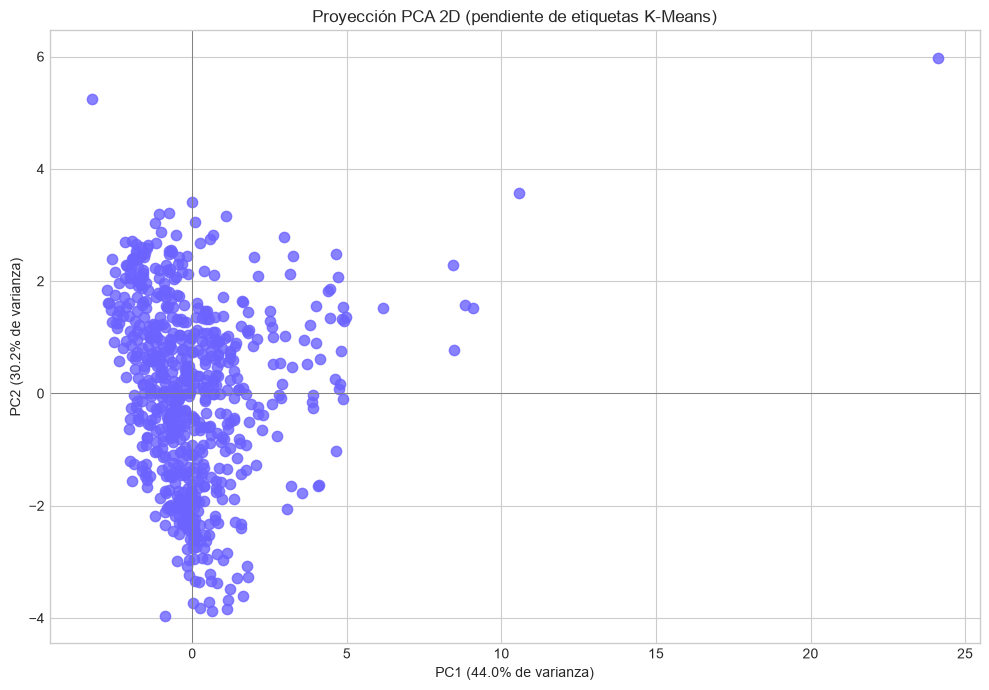

In [12]:
# BLOQUE 7 — Representar PC1 frente a PC2


plot_df = scores_df.copy()
plot_hue_column = None

# Cuando la responsable de K-Means entregue las etiquetas definitivas,
# el notebook las añadirá por pl_name para colorear la proyección.
if not USE_DEMO_DATA and cluster_labels_path.exists():
    cluster_labels = pd.read_csv(cluster_labels_path)
    required_cluster_columns = {ID_COLUMN, CLUSTER_COLUMN}
    missing_cluster_columns = required_cluster_columns.difference(cluster_labels.columns)
    if missing_cluster_columns:
        raise ValueError(
            f"El archivo de clusters no contiene: {sorted(missing_cluster_columns)}"
        )
    plot_df = plot_df.merge(
        cluster_labels[[ID_COLUMN, CLUSTER_COLUMN]],
        on=ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
    plot_hue_column = CLUSTER_COLUMN

fig, ax = plt.subplots(figsize=(10, 7))

if plot_hue_column is not None:
    for cluster_value, cluster_data in plot_df.groupby(plot_hue_column, dropna=False):
        ax.scatter(
            cluster_data["PC1"],
            cluster_data["PC2"],
            alpha=0.8,
            s=55,
            label=str(cluster_value),
        )
    ax.legend(title=plot_hue_column)
    plot_title = "Proyección PCA 2D por cluster"
else:
    ax.scatter(plot_df["PC1"], plot_df["PC2"], color="#6C63FF", alpha=0.8, s=55)
    plot_title = "Proyección PCA 2D (pendiente de etiquetas K-Means)"

ax.axhline(0, color="grey", linewidth=0.7)
ax.axvline(0, color="grey", linewidth=0.7)
ax.set_title(plot_title)
ax.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%} de varianza)")
ax.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%} de varianza)")
plt.tight_layout()
plt.show()

### Conclusión del bloque 7

La proyección PC1–PC2 resume el **74,22 %** de la varianza. Es útil para comunicar la estructura general, pero K-Means debe recibir las cuatro componentes.

## Bloque 8. Proyección tridimensional


Se añade PC3 cuando existen al menos tres componentes. Esta vista ayuda a observar la dimensión dominada por excentricidad, aunque sigue siendo una simplificación del espacio final de cuatro dimensiones.

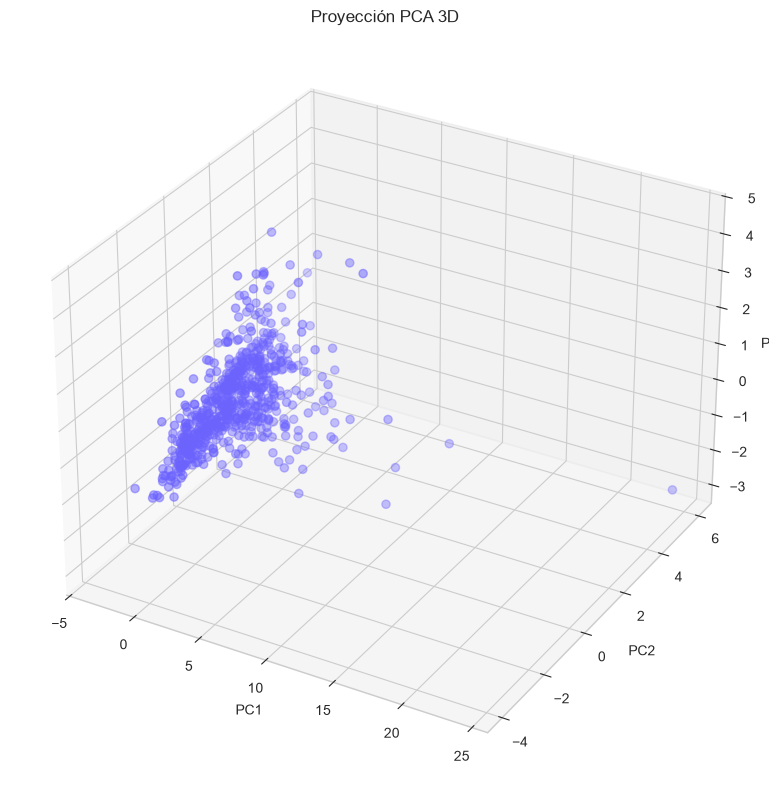

In [13]:
# BLOQUE 8 — Representar PC1, PC2 y PC3


if n_components >= 3:
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    if plot_hue_column is not None and plot_hue_column in plot_df.columns:
        categories = sorted(plot_df[plot_hue_column].dropna().unique())
        color_map = plt.get_cmap("tab10")
        palette = {
            category: color_map(index % 10)
            for index, category in enumerate(categories)
        }
        colors = plot_df[plot_hue_column].map(palette)
    else:
        colors = "#6C63FF"

    ax.scatter(
        plot_df["PC1"],
        plot_df["PC2"],
        plot_df["PC3"],
        c=colors,
        alpha=0.75,
        s=35,
    )
    ax.set(
        title="Proyección PCA 3D",
        xlabel="PC1",
        ylabel="PC2",
        zlabel="PC3",
    )
    plt.tight_layout()
    plt.show()
else:
    print("El modelo ha retenido menos de tres componentes; no se genera la proyección 3D.")

### Conclusión del bloque 8

La proyección PC1–PC3 representa el **83,81 %** de la varianza. Todavía omite PC4, por lo que se utiliza solo como apoyo visual.

## Bloque 9. Comprobaciones de consistencia


Las aserciones verifican dimensiones, identificadores, ausencia de nulos, forma de los loadings y cumplimiento del umbral. También se calcula el error medio de reconstrucción como medida descriptiva de la información descartada.

In [14]:
# BLOQUE 9 — Validar scores, loadings, varianza y corte temporal

assert scores_df.shape == (len(df), n_components + 1)
assert len(scores_df) == EXPECTED_ROWS
assert scores_df[ID_COLUMN].is_unique
assert not scores_df[component_names].isna().any().any()
assert loadings_df.shape == (len(FEATURE_COLUMNS), n_components)
assert 0 < retained_variance <= 1
assert retained_variance >= VARIANCE_THRESHOLD or n_components == full_pca.n_components_

if not USE_DEMO_DATA:
    assert preprocessing_metadata["max_discovery_year"] == EXPECTED_MAX_DISCOVERY_YEAR
    assert year_check["disc_year"].max() <= EXPECTED_MAX_DISCOVERY_YEAR

reconstruction = pca_model.inverse_transform(scores_df[component_names])
reconstruction_mse = float(np.mean((X_scaled.to_numpy() - reconstruction) ** 2))

checks = pd.Series(
    {
        "observaciones": len(scores_df),
        "año_máximo": EXPECTED_MAX_DISCOVERY_YEAR,
        "variables_de_entrada": len(FEATURE_COLUMNS),
        "componentes_retenidos": n_components,
        "varianza_retenida": retained_variance,
        "error_medio_reconstruccion": reconstruction_mse,
    },
    name="resultado",
)
display(checks.to_frame().round(6))
print("Comprobaciones superadas.")

,resultado
observaciones,675.000000
año_máximo,2025.000000
variables_de_entrada,12.000000
componentes_retenidos,4.000000
varianza_retenida,0.901999
error_medio_reconstruccion,0.068419


Comprobaciones superadas.


### Conclusión del bloque 9

Todas las pruebas pasan: **675 observaciones**, año máximo 2025, 12 variables y 4 componentes. La varianza retenida es **0,901999** y el error medio de reconstrucción es **0,068419**.

## Bloque 10. Exportación y entrega al equipo


Se guardan scores, varianza, loadings, modelo y metadata. La metadata documenta el orden de entrada y evita que otro miembro aplique PCA con columnas intercambiadas. Si llegan etiquetas de K-Means, solo se integrarán para visualizar y perfilar.

In [15]:
# BLOQUE 10 — Exportar los artefactos reproducibles de PCA

metadata = {
    "source_mode": source_mode,
    "input_path": str(processed_path),
    "preprocessing_metadata_path": str(preprocessing_metadata_path),
    "id_column": ID_COLUMN,
    "feature_columns": FEATURE_COLUMNS,
    "data_already_scaled": DATA_ALREADY_SCALED,
    "max_discovery_year": EXPECTED_MAX_DISCOVERY_YEAR,
    "input_rows": len(df),
    "variance_threshold": VARIANCE_THRESHOLD,
    "n_components": n_components,
    "retained_variance": retained_variance,
    "random_state": RANDOM_STATE,
}

if EXPORT_ARTIFACTS:
    output_dir.mkdir(parents=True, exist_ok=True)
    scores_df.to_csv(output_dir / "pca_scores.csv", index=False)
    explained_variance.to_csv(output_dir / "pca_explained_variance.csv", index=False)
    loadings_df.to_csv(output_dir / "pca_loadings.csv", index_label="variable")
    joblib.dump(pca_model, output_dir / "pca_model.joblib")
    if scaler_used_here is not None:
        joblib.dump(scaler_used_here, output_dir / "pca_local_scaler.joblib")
    (output_dir / "pca_metadata.json").write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    print(f"Artefactos exportados en: {output_dir}")
else:
    print("Exportación desactivada: la ejecución usa datos de demostración.")

display(pd.Series(metadata, name="valor").to_frame())

Artefactos exportados en: C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_modulo3\exoplanet-profiler\data\processed\pca


,valor
source_mode,DATOS REALES PREPROCESADOS HASTA 2025
input_path,C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_mo...
preprocessing_metadata_path,C:\PROYECTOS_ELE\BOOTCAMP_MODULO3\proyecto2_mo...
id_column,pl_name
feature_columns,"[pl_orbper, pl_orbsmax, pl_rade, pl_bmasse, pl..."
data_already_scaled,True
max_discovery_year,2025
input_rows,675
variance_threshold,0.85
n_components,4


### Conclusión del bloque 10

El siguiente notebook debe usar `data/processed/pca/pca_scores.csv`, con `pl_name` y PC1–PC4 para **675 planetas hasta 2025**.

`pl_name` conserva la trazabilidad, pero no entra en K-Means:

```python
X_kmeans = pca_scores[["PC1", "PC2", "PC3", "PC4"]]
```

Las cuatro componentes conservan el **90,20 %** de la varianza.

## Limitaciones del análisis

### Alcance temporal

PCA describe exclusivamente los 675 planetas retenidos hasta 2025. No debe generalizarse automáticamente a descubrimientos de 2026.

### Incertidumbre en `pl_insol`

Una proporción relevante de insolación procede de imputación KNN. Sus resultados deben interpretarse junto con otras propiedades y no como evidencia aislada de habitabilidad.

### PCA solo describe variación lineal

PCA puede perder relaciones no lineales. Las proyecciones 2D y 3D tampoco demuestran por sí solas la existencia de clusters.

La selección posterior de K debe combinar inercia, silhouette, tamaños, estabilidad e interpretación física.